In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [14]:
train_full_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

In [15]:
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_full_dataset, [train_size, val_size]
)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
def train_model(model, optimizer, train_loader, val_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

    # ===== TEST =====
    model.eval()
    correct, total = 0, 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss /= len(test_loader)

    return train_losses, val_losses, train_accs, val_accs, test_acc, test_loss

Experiment 1 — Adam

In [19]:
model_adam = CNN().to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

adam_results = train_model(
    model_adam,
    optimizer_adam,
    train_loader,
    val_loader,
    test_loader,
    epochs=10
)

Epoch 1 | Train Loss: 1.4948 | Train Acc: 46.05% | Val Loss: 1.1633 | Val Acc: 57.04%
Epoch 2 | Train Loss: 1.1673 | Train Acc: 58.58% | Val Loss: 0.9874 | Val Acc: 64.78%
Epoch 3 | Train Loss: 1.0344 | Train Acc: 63.56% | Val Loss: 0.9051 | Val Acc: 68.34%
Epoch 4 | Train Loss: 0.9512 | Train Acc: 66.89% | Val Loss: 0.8242 | Val Acc: 70.89%
Epoch 5 | Train Loss: 0.9060 | Train Acc: 68.32% | Val Loss: 0.7780 | Val Acc: 72.66%
Epoch 6 | Train Loss: 0.8530 | Train Acc: 70.37% | Val Loss: 0.7735 | Val Acc: 73.08%
Epoch 7 | Train Loss: 0.8263 | Train Acc: 71.19% | Val Loss: 0.7161 | Val Acc: 74.50%
Epoch 8 | Train Loss: 0.7920 | Train Acc: 72.83% | Val Loss: 0.7249 | Val Acc: 74.98%
Epoch 9 | Train Loss: 0.7616 | Train Acc: 73.84% | Val Loss: 0.6867 | Val Acc: 76.19%
Epoch 10 | Train Loss: 0.7305 | Train Acc: 74.85% | Val Loss: 0.6818 | Val Acc: 76.10%


Experiment 2 — SGD

In [20]:
model_sgd = CNN().to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

sgd_results = train_model(
    model_sgd,
    optimizer_sgd,
    train_loader,
    val_loader,
    test_loader,
    epochs=10
)

Epoch 1 | Train Loss: 1.6437 | Train Acc: 39.91% | Val Loss: 1.3589 | Val Acc: 50.48%
Epoch 2 | Train Loss: 1.3469 | Train Acc: 51.09% | Val Loss: 1.2156 | Val Acc: 56.18%
Epoch 3 | Train Loss: 1.2150 | Train Acc: 56.37% | Val Loss: 1.1333 | Val Acc: 59.40%
Epoch 4 | Train Loss: 1.1239 | Train Acc: 59.98% | Val Loss: 0.9951 | Val Acc: 63.99%
Epoch 5 | Train Loss: 1.0553 | Train Acc: 62.34% | Val Loss: 0.9740 | Val Acc: 65.19%
Epoch 6 | Train Loss: 0.9923 | Train Acc: 64.61% | Val Loss: 0.9340 | Val Acc: 66.52%
Epoch 7 | Train Loss: 0.9480 | Train Acc: 66.38% | Val Loss: 0.8796 | Val Acc: 68.50%
Epoch 8 | Train Loss: 0.9157 | Train Acc: 67.75% | Val Loss: 0.8480 | Val Acc: 69.89%
Epoch 9 | Train Loss: 0.8858 | Train Acc: 68.89% | Val Loss: 0.8460 | Val Acc: 70.35%
Epoch 10 | Train Loss: 0.8471 | Train Acc: 70.26% | Val Loss: 0.7905 | Val Acc: 71.83%


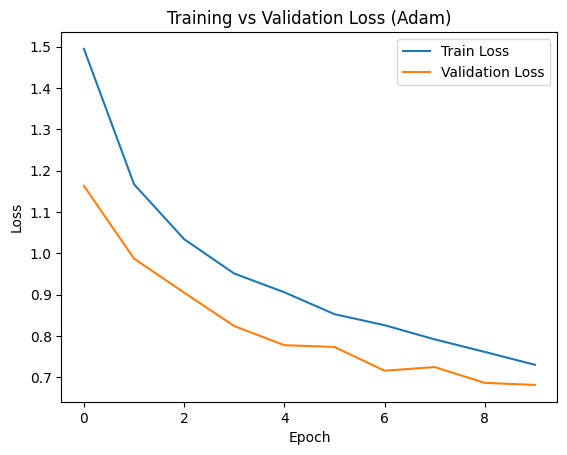

In [21]:
plt.figure()
plt.plot(adam_results[0], label="Train Loss")
plt.plot(adam_results[1], label="Validation Loss")
plt.title("Training vs Validation Loss (Adam)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

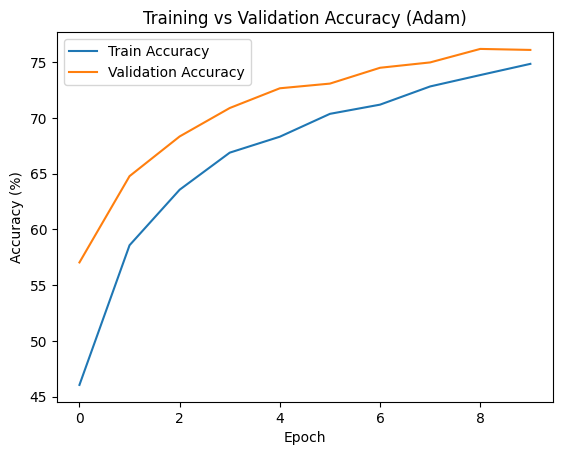

In [22]:
plt.figure()
plt.plot(adam_results[2], label="Train Accuracy")
plt.plot(adam_results[3], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (Adam)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

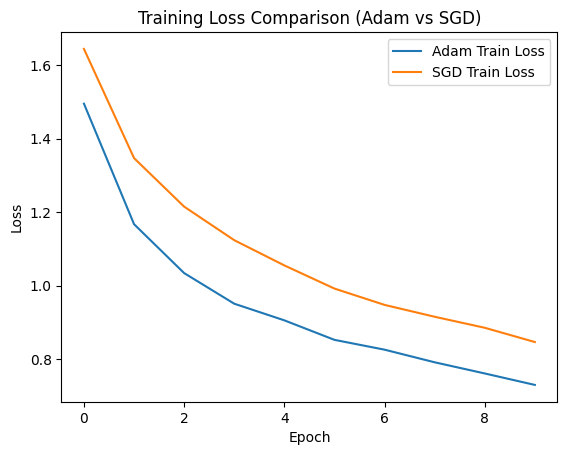

In [23]:
plt.figure()
plt.plot(adam_results[0], label="Adam Train Loss")
plt.plot(sgd_results[0], label="SGD Train Loss")
plt.title("Training Loss Comparison (Adam vs SGD)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

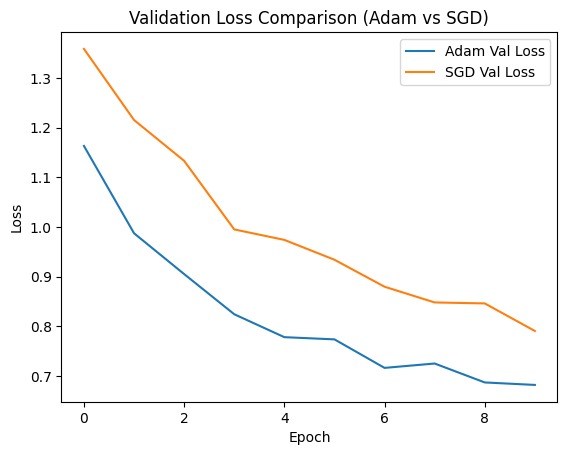

In [24]:
plt.figure()
plt.plot(adam_results[1], label="Adam Val Loss")
plt.plot(sgd_results[1], label="SGD Val Loss")
plt.title("Validation Loss Comparison (Adam vs SGD)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

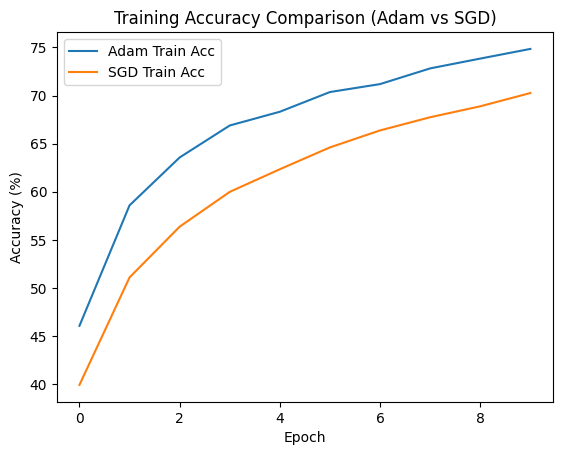

In [25]:
plt.figure()
plt.plot(adam_results[2], label="Adam Train Acc")
plt.plot(sgd_results[2], label="SGD Train Acc")
plt.title("Training Accuracy Comparison (Adam vs SGD)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

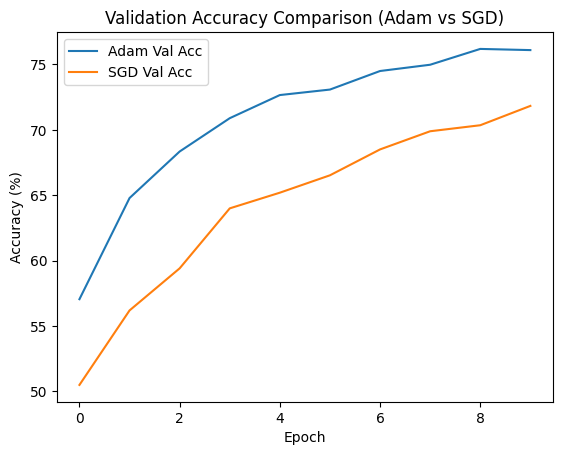

In [26]:
plt.figure()
plt.plot(adam_results[3], label="Adam Val Acc")
plt.plot(sgd_results[3], label="SGD Val Acc")
plt.title("Validation Accuracy Comparison (Adam vs SGD)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [27]:
print("| Model | Optimizer | Test Accuracy | Test Loss |")
print("|------|----------|--------------|----------|")
print(f"| A | Adam | {adam_results[4]:.2f}% | {adam_results[5]:.4f} |")
print(f"| B | SGD  | {sgd_results[4]:.2f}% | {sgd_results[5]:.4f} |")

| Model | Optimizer | Test Accuracy | Test Loss |
|------|----------|--------------|----------|
| A | Adam | 77.75% | 0.6550 |
| B | SGD  | 74.48% | 0.7331 |
